In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv(r"C:\Users\kylen\Desktop\My Projects\retail_sales_dashboard\data\raw\Online_Retail.csv", encoding="latin1")

In [5]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/10 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/10 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/10 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/10 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/10 8:34,1.69,13047.0,United Kingdom


In [6]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/11 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df.shape

(541909, 8)

In [9]:
# 1, Drop duplicates
df = df.drop_duplicates()

In [10]:
df.shape

(536641, 8)

In [11]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,536641,536641,535187,536641.000000,536641,536641.000000,401604.000000,536641
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/11 14:41,NaN,NaN,United Kingdom
freq,1114,2301,2357,NaN,1114,NaN,NaN,490300
mean,NaN,NaN,NaN,9.620029,NaN,4.632656,15281.160818,NaN
std,NaN,NaN,NaN,219.130156,NaN,97.233118,1714.006089,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13939.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15145.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16784.000000,NaN


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  object 
 1   StockCode    536641 non-null  object 
 2   Description  535187 non-null  object 
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  object 
 5   UnitPrice    536641 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      536641 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 36.8+ MB


In [13]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [14]:
# 2, Handle missing values
# Handling missing description
# Fill missing descriptions with "Unknown"
df['Description'] = df['Description'].fillna("Unknown")

In [15]:
# Handling missing CustomerID (guest checkout or anonymous customer)
# Fill missing CustomerID with "Guest"
df['CustomerID'] = df['CustomerID'].fillna("Guest")

In [16]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/10 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/10 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/10 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/10 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/10 8:34,1.69,13047.0,United Kingdom


In [ ]:
# 3, Fix Data Types
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    format='%m/%d/%y %H:%M' # Adjust format as needed
)

In [18]:
# Convert CustomerID and StockCode to categorical types
df['CustomerID'] = df['CustomerID'].astype('category')
df['StockCode'] = df['StockCode'].astype('category')

In [19]:
# 4, Feature Engineering (Create new features)
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

In [20]:
# Identify Cancelled Orders
df['IsCancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')
# Convert CustomerID back to string for consistency
df['CustomerID'] = df['CustomerID'].astype(str)

In [21]:
# 5, Remove Invalid Entries
df = df[df['Quantity'] > 0] # Remove entries with negative quantity
df = df[df['UnitPrice'] > 0] # Remove entries with negative unit price

<Axes: >

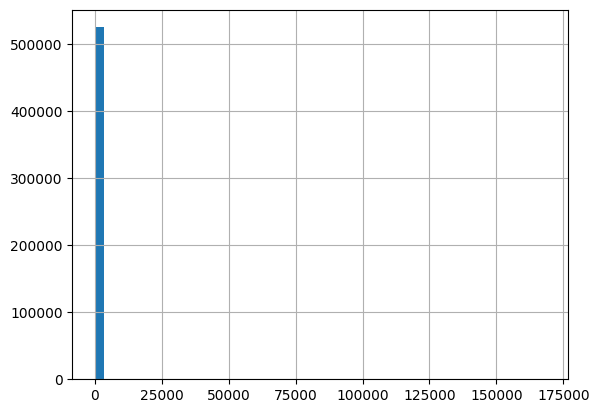

In [ ]:
#-------------
# EDA TIME
#-------------
# Distribution of Revenue
df['Revenue'].hist(bins=50)

In [ ]:
# Top 10 countries by total revenue
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [27]:
# Top 20 products by total revenue
df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

<Axes: xlabel='Year,Month'>

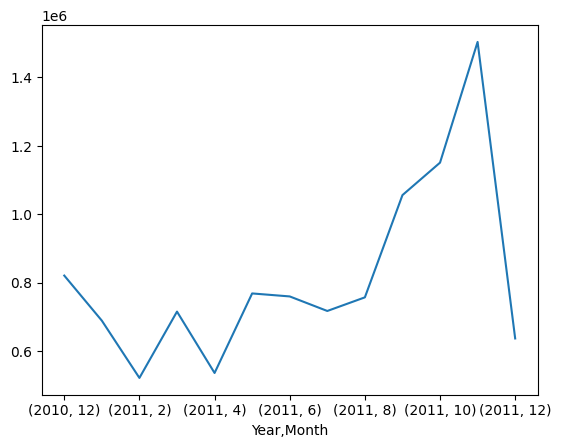

In [ ]:
# Monthly revenue trends
df.groupby(['Year', 'Month'])['Revenue'].sum().plot(kind='line')

In [29]:
#-------------------------
# Customer-Level Analysis
#-------------------------
# Top 5 customers by total revenue
df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head()

CustomerID
Guest      1754901.91
14646.0     280206.02
18102.0     259657.30
17450.0     194390.79
16446.0     168472.50
Name: Revenue, dtype: float64

In [30]:
# Top 5 customers by number of unique invoices
df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False).head()

CustomerID
Guest      1428
12748.0     209
14911.0     201
17841.0     124
13089.0      97
Name: InvoiceNo, dtype: int64

In [32]:
#--------------------------
# Product-Level Analysis
#--------------------------
# Top 5 products by quantity sold (Best sellers)
df.groupby('StockCode', observed=True)['Quantity'].sum().sort_values(ascending=False).head()

StockCode
23843     80995
23166     78033
22197     56898
84077     54951
85099B    48371
Name: Quantity, dtype: int64

In [ ]:
# Top 5 products by total revenue (Highest revenue items)
df.groupby('StockCode', observed=True)['Revenue'].sum().sort_values(ascending=False).head()

StockCode
DOT       206248.77
22423     174156.54
23843     168469.60
85123A    104462.75
47566      99445.23
Name: Revenue, dtype: float64

C:\Users\kylen\AppData\Local\Temp\ipykernel_9496\2304380998.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('InvoiceDate').resample('M')['Revenue'].sum().plot()


<Axes: xlabel='InvoiceDate'>

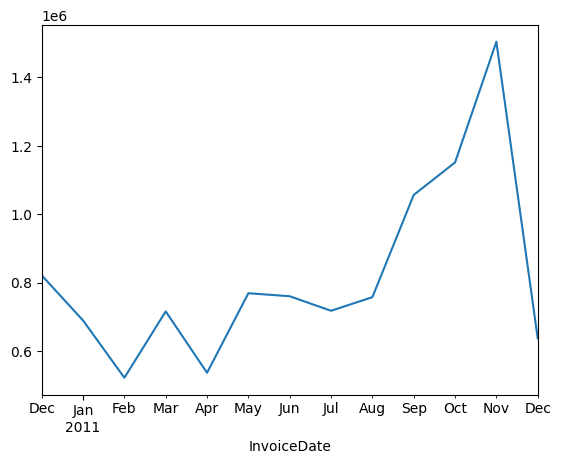

In [34]:
#----------------------
# Time-Based Analysis
#----------------------
# Revenue per month
df.set_index('InvoiceDate').resample('M')['Revenue'].sum().plot()

<Axes: xlabel='Weekday'>

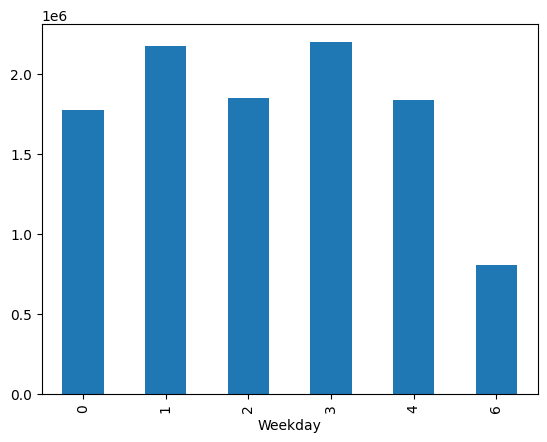

In [35]:
# Revenue by weekday
df['Weekday'] = df['InvoiceDate'].dt.weekday
df.groupby('Weekday')['Revenue'].sum().plot(kind='bar')